In [31]:
import pandas as pd
import numpy as np
import joblib
from lime.lime_tabular import LimeTabularExplainer
import shap
import seaborn as sns
import matplotlib.pyplot as plt
import re
from alibi.explainers import AnchorTabular

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

shap.initjs() # Enables us to generate SHAP plots

In [32]:
# We are calling our train_df as historical_df.
historical_df = pd.read_csv('../data/historical.csv')
misclassified_df = pd.read_csv('../data/corrected_false_negatives.csv')

# the model by data monitors as old_model
old_model = joblib.load("../data/model.joblib")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying

In [33]:
queries = [
    (
        f"baby_id == '{baby[0]}' "
        f"and name == '{baby[1]}' "
        f"and gender == '{baby[2]}' "
        f"and date == '{baby[3]}'"
    )
    for baby in misclassified_df.values
]


In [34]:
features = historical_df.columns[:-1]
X_hist = historical_df[features]

# LIME

Just for the preprocessing, notice below that even though there are 7 categorical features as listed below, only four of them remain in use. The other three are dropped.

- **baby_id** → identifier (DROPPED)
- **name** → identifier (DROPPED)
- **gender** → categorical (binary / nominal)  
- **date** → stored as object (DROPPED)
- **feeding_type** → categorical  
- **immunizations_done** → categorical (yes/no type)  
- **reflexes_normal** → categorical (yes/no type)  

Surprisingly, the preprocessor also dropped the 'apgar_score'.

In [35]:
# These are the four variables that were not dropped
preprocessor = old_model['preprocess']
print('Categorical Features Used in the Old Model:')
for cat_feature in preprocessor.transformers_[1][2]:
    print(cat_feature)

print('')

print('Numerical Features Used in the Old Model:')
for num_feature in preprocessor.transformers_[0][2]:
    print(num_feature)

Categorical Features Used in the Old Model:
gender
feeding_type
immunizations_done
reflexes_normal

Numerical Features Used in the Old Model:
gestational_age_weeks
birth_weight_kg
birth_length_cm
birth_head_circumference_cm
age_days
weight_kg
length_cm
head_circumference_cm
temperature_c
heart_rate_bpm
respiratory_rate_bpm
oxygen_saturation
feeding_frequency_per_day
urine_output_count
stool_count
jaundice_level_mg_dl


In [36]:
# Drop unused columns
dropped_columns = ['baby_id', 'name', 'date', 'apgar_score']
X_encoded = X_hist.copy()
X_encoded = X_encoded.drop(columns=dropped_columns)

# Identify categorical features
categorical_features = preprocessor.transformers_[1][2]  
categorical_indices = [X_encoded.columns.get_loc(col) for col in categorical_features]

# Encode categorical columns as integers
categorical_names = {}
for idx, feature in zip(categorical_indices, categorical_features):
    X_encoded[feature] = X_encoded[feature].astype("category").cat.codes
    categorical_names[idx] = list(X_encoded[feature].astype("category").cat.categories)

# Ensure numeric columns are float
numeric_features = [col for col in X_encoded.columns if col not in categorical_features]
X_encoded[numeric_features] = X_encoded[numeric_features].astype(float)

# Create the LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_encoded.values,
    feature_names=X_encoded.columns.tolist(),
    class_names=['Healthy', 'At Risk'],
    categorical_features=categorical_indices,
    categorical_names=categorical_names,
    kernel_width=3
)


Because we manually dropped the unused variables for LIME, we have to recreate the preprocesser of the old_model. Luckily, it isn't that hard since we have the parameters based on the old_model.

In [37]:
# ColumnTransformer
recreated_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), preprocessor.transformers_[0][2]),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), preprocessor.transformers_[1][2])
    ],
    remainder='drop'   # drops baby_id, name, date (in case it hasn't been dropped beforehand)
)

recreated_preprocessor.fit(X_encoded)

# Create an anonymous function where given a sample, it predicts using the rf model
def predict_fn(baby):
    baby_df = pd.DataFrame(baby, columns=X_encoded.columns)
    baby_transformed = recreated_preprocessor.transform(baby_df)
    return old_model['clf'].predict_proba(baby_transformed)


In [38]:
lime_results = []

for i in range(len(queries)):
    misclassified_baby = historical_df.query(queries[i])
    #print(f"{misclassified_baby['name'].iloc[0]} of index {misclassified_baby.index[0]} "
    #      f"was misclassified as healthy on {misclassified_baby['date'].iloc[0]}")
    row_index = misclassified_baby.index[0]

    exp = explainer.explain_instance(
        X_encoded.iloc[row_index].values,   # 1D numpy array
        predict_fn,
        num_features=5
    )

    for feature, weight in exp.as_list():
        lime_results.append({
            "sample_id": i,
            "feature": feature,
            "weight": weight
        })

    #exp.show_in_notebook(show_all=True)

In [39]:
for i in [215, 840]:
    misclassified_baby = historical_df.loc[i]
    print(f"{misclassified_baby['name']} of index {i} "
          f"was misclassified as healthy on {misclassified_baby['date']}")

    exp = explainer.explain_instance(
        X_encoded.iloc[i].values,   # 1D numpy array
        predict_fn,
        num_features=5
    )

    exp.show_in_notebook(show_all=True)

Jerome of index 215 was misclassified as healthy on 2024-12-07


Adam of index 840 was misclassified as healthy on 2024-11-01


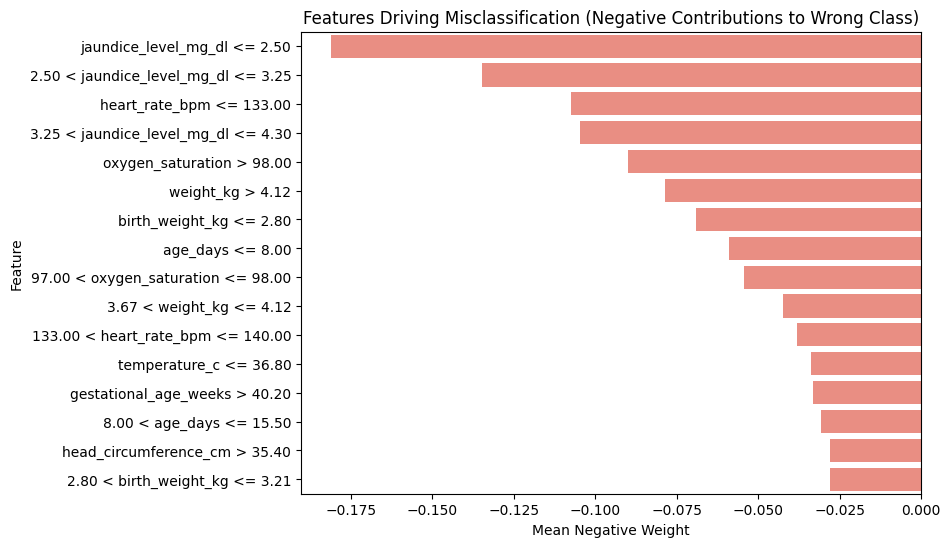

In [40]:
df_lime = pd.DataFrame(lime_results)

def extract_base_feature(s):
    # Matches longest word (letters, underscores, maybe digits) in the string
    match = re.search(r"[A-Za-z_][A-Za-z0-9_]*", s)
    return match.group(0) if match else s

df_lime["base_feature"] = df_lime["feature"].apply(extract_base_feature)

df_wrong = df_lime[df_lime["weight"] < 0]

agg_wrong = df_wrong.groupby("feature")["weight"].mean().sort_values(ascending=True)

plt.figure(figsize=(8,6))
sns.barplot(x=agg_wrong.values, y=agg_wrong.index, color="salmon")
plt.title("Features Driving Misclassification (Negative Contributions to Wrong Class)")
plt.xlabel("Mean Negative Weight")
plt.ylabel("Feature")
plt.show()


# Anchor

In [44]:
# # Wrap model prediction for Anchor
def predictor(X):
    baby_df = pd.DataFrame(X, columns=X_encoded.columns)
    baby_transformed = recreated_preprocessor.transform(baby_df)
    return old_model['clf'].predict(baby_transformed)

explainer = AnchorTabular(
    predictor=predictor,
    feature_names=X_encoded.columns.tolist(),
    categorical_names=categorical_names
)

# Fit on training data
explainer.fit(
    X_encoded.values.astype(np.float64),   # match dtypes
    disc_perc=[25, 50, 75]
)

# Pick an instance to explain
instance = X_encoded.iloc[0].values.reshape(1, -1).astype(np.float64)
print("Model prediction:", predictor(instance))

# Generate explanation
explanation = explainer.explain(instance)

print("\nAnchor rule:", explanation.anchor)
print("Precision:", explanation.precision)
print("Coverage:", explanation.coverage)

Model prediction: [0]

Anchor rule: ['jaundice_level_mg_dl <= 4.30']
Precision: 1.0
Coverage: 0.7514


# Individual Conditional Expectation (ICE)

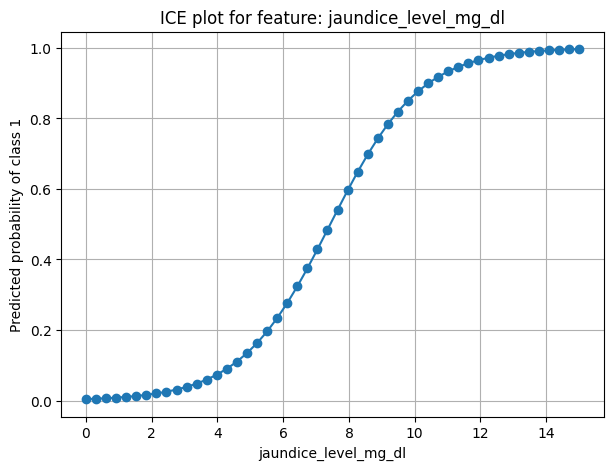

In [45]:
instance = X_encoded.iloc[[0]].copy()

# Feature to analyze
feature = "jaundice_level_mg_dl"

# Define a grid of possible values for this feature
feature_values = np.linspace(0, 15, 50)  # adjust range to your domain

# Store predictions
preds = []

for val in feature_values:
    # Copy the instance and replace the feature with val
    temp = instance.copy()
    temp[feature] = val
    
    # Pass through preprocessor and model
    temp_transformed = recreated_preprocessor.transform(temp)
    pred = old_model['clf'].predict_proba(temp_transformed)[0, 1]  # probability of class 1
    preds.append(pred)

# Plot ICE curve
plt.figure(figsize=(7,5))
plt.plot(feature_values, preds, marker="o")
plt.xlabel(feature)
plt.ylabel("Predicted probability of class 1")
plt.title(f"ICE plot for feature: {feature}")
plt.grid(True)
plt.show()


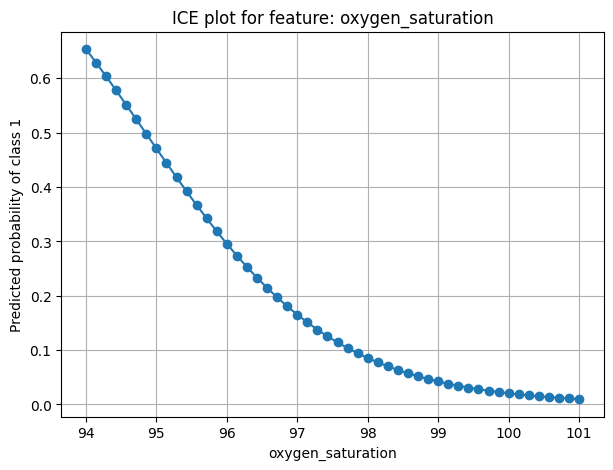

In [53]:
instance = X_encoded.iloc[[0]].copy()

# Feature to analyze
feature = "oxygen_saturation"

# Define a grid of possible values for this feature
feature_values = np.linspace(94, 101, 50)  # adjust range to your domain

# Store predictions
preds = []

for val in feature_values:
    # Copy the instance and replace the feature with val
    temp = instance.copy()
    temp[feature] = val
    
    # Pass through preprocessor and model
    temp_transformed = recreated_preprocessor.transform(temp)
    pred = old_model['clf'].predict_proba(temp_transformed)[0, 1]  # probability of class 1
    preds.append(pred)

# Plot ICE curve
plt.figure(figsize=(7,5))
plt.plot(feature_values, preds, marker="o")
plt.xlabel(feature)
plt.ylabel("Predicted probability of class 1")
plt.title(f"ICE plot for feature: {feature}")
plt.grid(True)
plt.show()


In [54]:
X_encoded['heart_rate_bpm'].describe()

count    2100.000000
mean      139.680476
std        10.234427
min       100.000000
25%       133.000000
50%       140.000000
75%       146.000000
max       173.000000
Name: heart_rate_bpm, dtype: float64

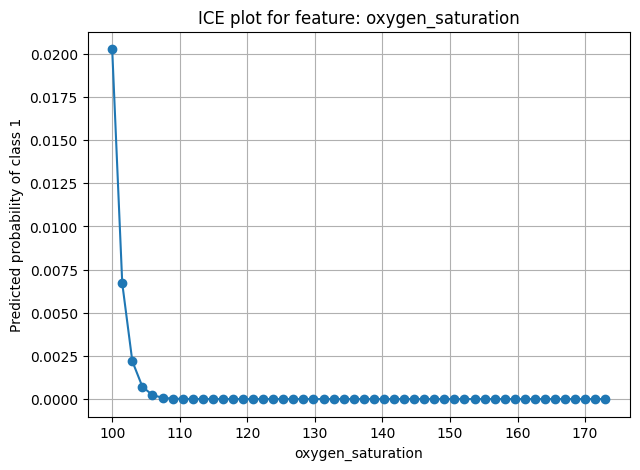

In [55]:
instance = X_encoded.iloc[[0]].copy()

# Feature to analyze
feature = "oxygen_saturation"

# Define a grid of possible values for this feature
feature_values = np.linspace(100, 173, 50)  # adjust range to your domain

# Store predictions
preds = []

for val in feature_values:
    # Copy the instance and replace the feature with val
    temp = instance.copy()
    temp[feature] = val
    
    # Pass through preprocessor and model
    temp_transformed = recreated_preprocessor.transform(temp)
    pred = old_model['clf'].predict_proba(temp_transformed)[0, 1]  # probability of class 1
    preds.append(pred)

# Plot ICE curve
plt.figure(figsize=(7,5))
plt.plot(feature_values, preds, marker="o")
plt.xlabel(feature)
plt.ylabel("Predicted probability of class 1")
plt.title(f"ICE plot for feature: {feature}")
plt.grid(True)
plt.show()


# Shapley Values

Using 2100 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/29 [00:00<?, ?it/s]

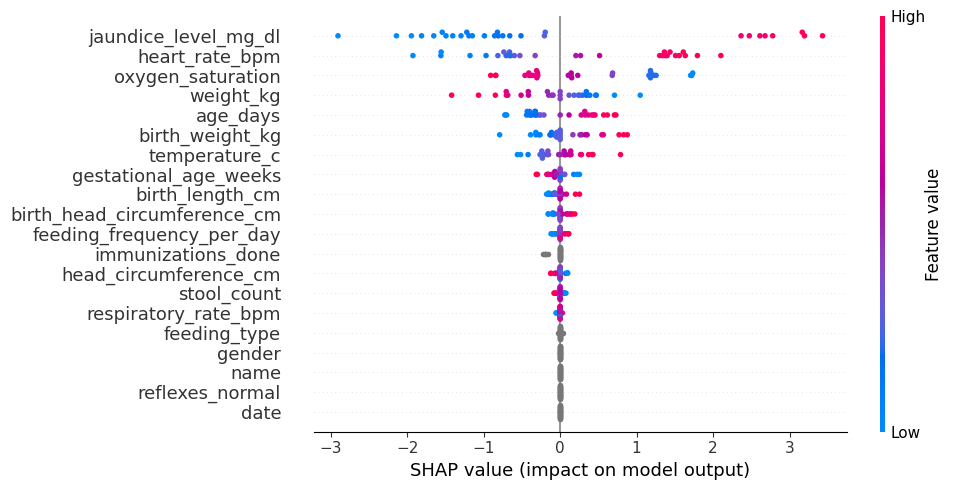

In [14]:
def model_fn(x: np.ndarray):
    """
    SHAP will pass numpy arrays (no column names).
    We re-wrap them into a DataFrame so the pipeline can handle them.
    """
    x_df = pd.DataFrame(x, columns=FEATURE_NAMES)
    return old_model.predict_proba(x_df)[:, class_idx]

shap_explainer = shap.KernelExplainer(
    model_fn,
    data=X_hist,
    link="logit", # since we're predicting probabilities, we set this to "logit"
)

X_misclassified = historical_df.merge(
    misclassified_df,
    on=['baby_id', 'name', 'gender', 'date'],
    how='inner'
).drop(columns=['risk_level'])

shap_values = shap_explainer.shap_values(X_misclassified)

shap.summary_plot(shap_values, X_misclassified, plot_size=(10,5))